### Preprocess

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from ultralytics.data.augment import LetterBox
import torch

def preprocess(im: torch.Tensor | list[np.ndarray]) -> torch.Tensor:
    not_tensor = not isinstance(im, torch.Tensor)
    if not_tensor:
        im = np.stack(pre_transform(im))
        if im.shape[-1] == 3:
            im = im[..., ::-1]  # BGR to RGB
        im = im.transpose((0, 3, 1, 2))  # BHWC to BCHW, (n, 3, h, w)
        im = np.ascontiguousarray(im)  # contiguous
        im = torch.from_numpy(im)

    im = im.to(device)
    im = im.half() if model_fp16 else im.float()  # uint8 to fp16/32
    if not_tensor:
        im /= 255  # 0 - 255 to 0.0 - 1.0
    return im

def pre_transform(im: list[np.ndarray]) -> list[np.ndarray]:
    letterbox = LetterBox(
        (640, 640),
        auto=len({x.shape for x in im}) == 1,
        stride=32,
    )
    return [letterbox(image=x) for x in im]

device = "cuda:0"
model_fp16 = False
image_path = "bus.jpg"

orig_img = cv2.imread(image_path)
orig_imgs = np.array([orig_img])
preprocessed_img = preprocess(orig_imgs)

### Postprocess

In [2]:
import torch
from ultralytics.engine.results import Results
from ultralytics.utils import nms, ops
import cv2
import matplotlib.pyplot as plt
import yaml

In [3]:
with open("coco.yaml", "r") as f:
    model_names = yaml.safe_load(f)
    model_names = dict(enumerate(model_names["names"]))

In [4]:
args_conf = 0.25
args_iou = 0.7
args_classes = None
args_agnostic_nms = False
args_max_det = 300
args_task = "detect"

save_feats = None
model_names_length = 80

In [23]:
preds = torch.load("tmp/preds.pt", weights_only=False)
nms_preds = nms.non_max_suppression(
    preds,
    args_conf,
    args_iou,
    args_classes,
    args_agnostic_nms,
    max_det=args_max_det,
    nc=0 if args_task == "detect" else model_names_length,
    end2end=True,
    rotated=args_task == "obb",
    return_idxs=save_feats,
)

# Original Result
results = []

for pred, orig_img in zip(preds, orig_imgs):
    pred = pred.squeeze(0)
    pred[:, :4] = ops.scale_boxes(
        preprocessed_img.shape[2:],
        pred[:, :4],
        orig_img.shape,
    )

    result = Results(
        orig_img,
        path="image_path",
        names=model_names,
        boxes=pred[:, :6],
    )

    results.append(result)

# NMS
nms_results = []

for pred, orig_img in zip(nms_preds, orig_imgs):
    pred[:, :4] = ops.scale_boxes(
        preprocessed_img.shape[2:],
        pred[:, :4],
        orig_img.shape,
    )

    nms_result = Results(
        orig_img,
        path="image_path",
        names=model_names,
        boxes=pred[:, :6],
    )

    nms_results.append(nms_result)

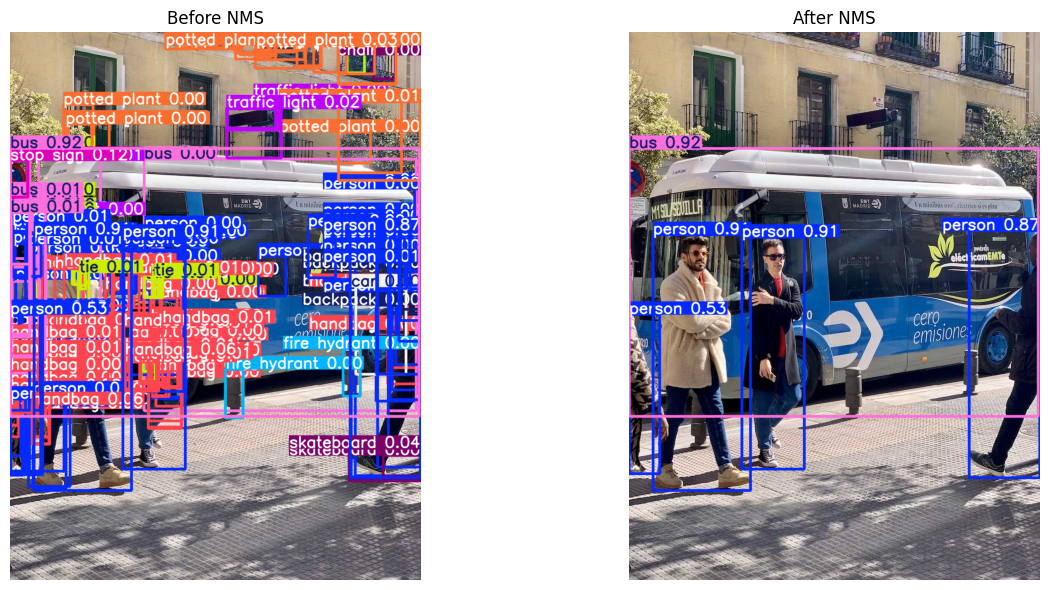

In [28]:
before_nms = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)
after_nms = cv2.cvtColor(nms_results[0].plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(before_nms)
plt.title("Before NMS")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(after_nms)
plt.title("After NMS")
plt.axis("off")

plt.tight_layout()
plt.show()

### See different configs

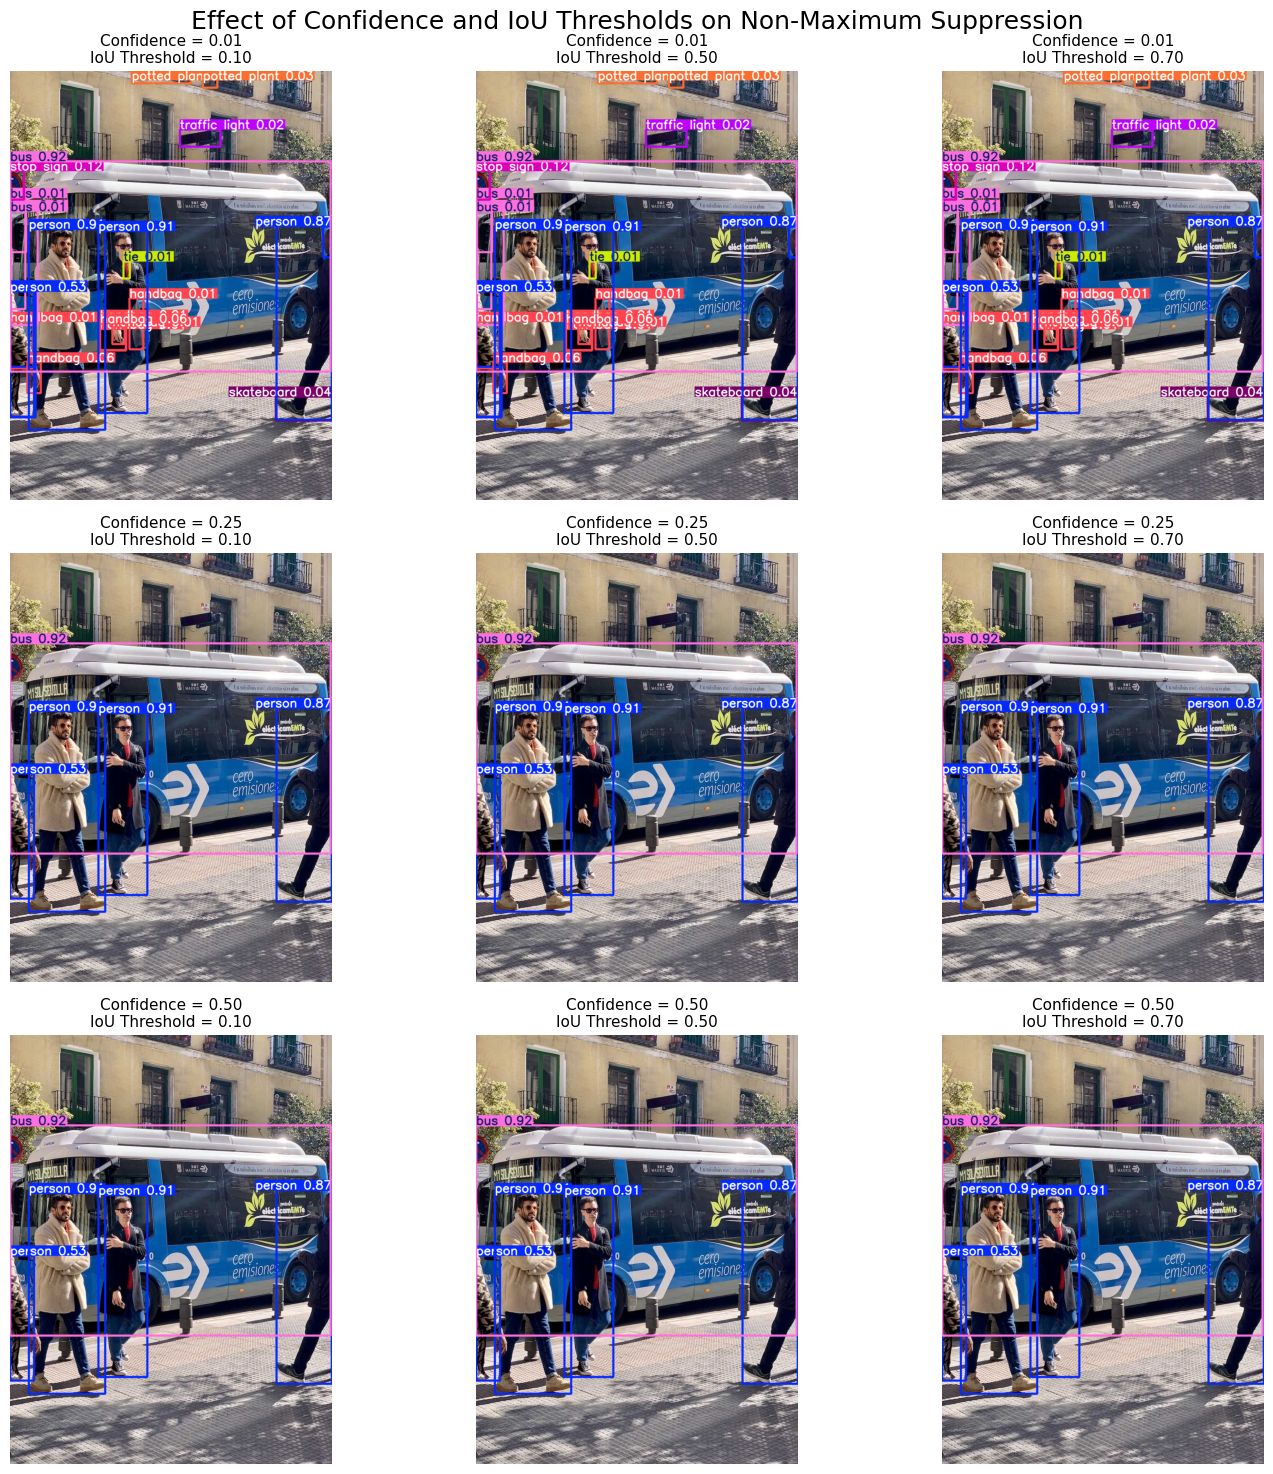

In [32]:
preds = torch.load("tmp/preds.pt", weights_only=False)

args_max_det = 300
args_classes = None
args_agnostic_nms = False

conf_values = [0.01, 0.25, 0.50]
iou_values = [0.10, 0.50, 0.70]

fig, axes = plt.subplots(
    len(conf_values),
    len(iou_values),
    figsize=(15, 15),
)

for i, conf in enumerate(conf_values):
    for j, iou in enumerate(iou_values):

        # NMS
        nms_preds = nms.non_max_suppression(
            preds,
            conf,
            iou,
            args_classes,
            args_agnostic_nms,
            max_det=args_max_det,
            nc=0,
            end2end=True,
            rotated=False,
            return_idxs=None,
        )

        # Build Results
        results = []
        for pred, orig_img in zip(nms_preds, orig_imgs):
            pred = pred.clone()

            pred[:, :4] = ops.scale_boxes(
                preprocessed_img.shape[2:],
                pred[:, :4],
                orig_img.shape,
            )

            results.append(
                Results(
                    orig_img,
                    path="image_path",
                    names=model_names,
                    boxes=pred[:, :6],
                )
            )

        # Plot first image
        img = cv2.cvtColor(results[0].plot(), cv2.COLOR_BGR2RGB)

        ax = axes[i, j]
        ax.imshow(img)
        ax.set_title(
            f"Confidence = {conf:.2f}\nIoU Threshold = {iou:.2f}",
            fontsize=11,
        )
        ax.axis("off")

plt.suptitle("Effect of Confidence and IoU Thresholds on Non-Maximum Suppression", fontsize=18)
plt.tight_layout()
plt.show()